In [53]:
import pandas as pd
import matplotlib.pyplot as plt
titanic_df = pd.read_csv('https://raw.githubusercontent.com/milatovicdanka90-maker/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv')

In [54]:
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [55]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [56]:
# Create a bar chart showing how many missing values are in each column
missing_values = titanic_df.isnull().sum()

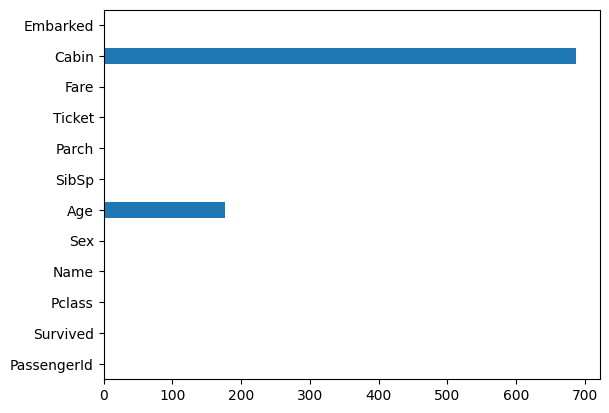

In [57]:
missing_values.plot(kind="barh");

In [58]:
# Which column has the most NaN values? How many cells in that column are empty?
missing_values = titanic_df.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [59]:
print(f'Column with the most NaN values is Cabin')
print(f'In the column there are 687 empty cells')

Column with the most NaN values is Cabin
In the column there are 687 empty cells


In [60]:
# Delete all rows where Embarked is empty
titanic_without_embarked_column = titanic_df.dropna(subset=['Embarked'])

In [61]:
titanic_without_embarked_column.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [62]:
# Fill all empty cabins with ¯\(ツ)/¯
titanic_df ['Cabin'] = titanic_df['Cabin'].fillna('¯\(ツ)/¯')
titanic_df.head()

<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2812/2550360908.py:2: SyntaxWarning: invalid escape sequence '\('
  titanic_df ['Cabin'] = titanic_df['Cabin'].fillna('¯\(ツ)/¯')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S


In [63]:
# There are two columns that pertain to how many family members are on the boat for a given person.
# Create a new column called FamilyCount which will be the sum of those two columns.

titanic_df['FamilyCount'] = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,¯\(ツ)/¯,Q,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,¯\(ツ)/¯,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,¯\(ツ)/¯,S,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,¯\(ツ)/¯,C,1


In [64]:
# Reverends have a special title in their name. Create a column called IsReverend: 1 if they're a preacher, 0 if they're not.
titanic_df_isreverend = []

for name in titanic_df["Name"]:
    if "Rev." in name:
        titanic_df_isreverend.append(1)
    else:
        titanic_df_isreverend.append(0)
titanic_df["IsReverend"] = titanic_df_isreverend
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,¯\(ツ)/¯,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,¯\(ツ)/¯,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,0


In [65]:
titanic_df[titanic_df["Name"].str.contains("Rev.")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.000,¯\(ツ)/¯,S,0,1
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.525,¯\(ツ)/¯,S,0,1
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.000,¯\(ツ)/¯,S,1,1
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.350,¯\(ツ)/¯,Q,0,1
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.000,¯\(ツ)/¯,S,1,1
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,¯\(ツ)/¯,S,0,1


In [66]:
# In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using pd.get_dummies
# Familiarize yourself with the pd.get_dummies documentation
# Create 3 columns: Embarked_C, Embarked_Q and Embarked_S. These columns will have 1's and 0's that correspond to the C,
# Q and S values in the Embarked column
embarked_dummies = pd.get_dummies(titanic_df["Embarked"], prefix="Embarked", dtype=int)
titanic_df = pd.concat([titanic_df, embarked_dummies], axis=1)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0,0,0,0,1


In [67]:
# Do the same thing for Sex
sex_dummies = pd.get_dummies(titanic_df["Sex"], prefix="Sex", dtype=int)
titanic_df = pd.concat([titanic_df, sex_dummies], axis=1)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1,0,0,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,1,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0,0,0,0,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0,0,0,1,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0,0,0,0,1,0,1


In [68]:
# What was the survival rate overall?

round(titanic_df["Survived"].mean() * 100, 2)

np.float64(38.38)

In [69]:
# Which gender fared the worst? What was their survival rate?
titanic_df.groupby('Sex')['Survived'].mean().round(2)

,Survived
Sex,
female,0.74
male,0.19


In [70]:
# What was the survival rate for each Pclass?
titanic_df.groupby('Pclass')['Survived'].mean().round(2)

,Survived
Pclass,
1,0.63
2,0.47
3,0.24


In [71]:
# Did any reverends survive? How many?
titanic_df[titanic_df["IsReverend"] == 1][["Name", "Survived"]]

,Name,Survived
149,"Byles, Rev. Thomas Roussel Davids",0
150,"Bateman, Rev. Robert James",0
249,"Carter, Rev. Ernest Courtenay",0
626,"Kirkland, Rev. Charles Leonard",0
848,"Harper, Rev. John",0
886,"Montvila, Rev. Juozas",0


In [72]:
titanic_df[titanic_df["IsReverend"] == 1]["Survived"].sum()

np.int64(0)

In [77]:
# What is the survival rate for cabins marked ¯\(ツ)/¯

titanic_df["Cabin"].value_counts()

,count
Cabin,
¯\(ツ)/¯,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


In [82]:
round(titanic_df[titanic_df["Cabin"] == "¯\(ツ)/¯"]["Survived"].mean() * 100, 2)

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2812/3719233966.py:1: SyntaxWarning: invalid escape sequence '\('
  round(titanic_df[titanic_df["Cabin"] == "¯\(ツ)/¯"]["Survived"].mean() * 100, 2)


np.float64(29.99)

In [83]:
# What is the survival rate for people whose Age is empty?
round(titanic_df[titanic_df["Age"].isnull()]["Survived"].mean() * 100, 2)

np.float64(29.38)

In [84]:
# What is the survival rate for each port of embarkation?
titanic_df.groupby('Embarked')['Survived'].mean().round(2)

,Survived
Embarked,
C,0.55
Q,0.39
S,0.34


In [85]:
# What is the survival rate for children (under 12) in each Pclass?
# What is the survival rate for children (under 12) in each Pclass?

round(titanic_df[titanic_df["Age"] < 12].groupby("Pclass")["Survived"].mean() * 100,2)

,Survived
Pclass,
1,75.00
2,100.00
3,40.43


In [89]:
# Did the captain of the ship survive? Is he on the list?

titanic_df[titanic_df["Name"].str.contains("Cap")][["Name", "Survived"]]

,Name,Survived
745,"Crosby, Capt. Edward Gifford",0


In [94]:
# Of all the people that died, who had the most expensive ticket? How much did it cost?

titanic_df[titanic_df["Survived"] == 0].sort_values("Fare", ascending=False)[["Name", "Fare"]].max()

,0
Name,"van Melkebeke, Mr. Philemon"
Fare,263.0


In [95]:
# Does having family on the boat help or hurt your chances of survival?

round(titanic_df.groupby(titanic_df["FamilyCount"] > 0)["Survived"].mean() * 100, 2)

,Survived
FamilyCount,
False,30.35
True,50.56


In [96]:
# Using matplotlib and seaborn, create several charts showing the survival rates of different groups of people.
# It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.
import seaborn as sns

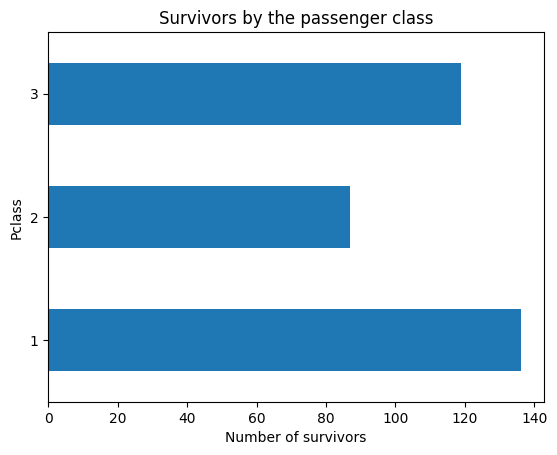

In [105]:
titanic_df.groupby("Pclass")["Survived"].sum().plot(kind="barh")

plt.xlabel("Number of survivors")
plt.ylabel("Pclass")
plt.title("Survivors by the passenger class")
plt.show()